# Tahap A — Cell [1]: Impor dan Persiapan Data

In [2]:
import os
import tensorflow as tf
import keras
from keras import layers
from keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

print(f"Keras Version: {keras.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# 1. Tentukan Konstanta dan Path
# ==========================================================
DATASET_DIR = os.path.join('ml-training', 'data') 
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
VAL_DIR = os.path.join(DATASET_DIR, 'val')

IMG_HEIGHT = 24
IMG_WIDTH = 24
BATCH_SIZE = 64

# ==========================================================
# 2. Persiapan Dataset (Cara BARU Keras 3)
# ==========================================================
# Kita tidak lagi pakai ImageDataGenerator.
# Kita gunakan 'image_dataset_from_directory'

print("Memuat dataset training...")
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='binary',        # 'binary' (0 atau 1)
    color_mode='grayscale',     # 'grayscale' (1 channel)
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

print("Memuat dataset validasi...")
val_ds = image_dataset_from_directory(
    VAL_DIR,
    label_mode='binary',
    color_mode='grayscale',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False # Tidak perlu diacak untuk validasi
)

print("\nDataset Selesai Dibuat.")
print(f"Label Kelas Ditemukan: {train_ds.class_names}") # -> ['awake', 'sleepy']

# 3. Optimasi Performa Dataset
# Kita 'cache' (simpan di memori) dan 'prefetch' (siapkan batch berikutnya)
# Ini membuat training jauh lebih cepat
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset dioptimalkan untuk performa.")

Keras Version: 3.12.0
TensorFlow Version: 2.20.0
Memuat dataset training...
Found 50937 files belonging to 2 classes.
Memuat dataset validasi...
Found 16980 files belonging to 2 classes.

Dataset Selesai Dibuat.
Label Kelas Ditemukan: ['awake', 'sleepy']
Dataset dioptimalkan untuk performa.


# Tahap A — Cell [2]: Membangun Arsitektur Model CNN

In [3]:
from keras import layers, models, Input

# 4. Membangun Arsitektur Model CNN (Cara Keras 3)
# ==========================================================

# --- a. Buat 'preprocessing' & 'augmentation' layers ---
# Normalisasi (Rescaling) menjadi layer
rescale_layer = layers.Rescaling(1./255)

# Augmentasi (mirip ImageDataGenerator dulu) menjadi layers
data_augmentation = models.Sequential([
    layers.RandomRotation(0.1),  # rotasi 10%
    layers.RandomZoom(0.1),      # zoom 10%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1) # geser 10%
], name="augmentation")

# --- b. Tentukan bentuk input ---
input_shape = (IMG_HEIGHT, IMG_WIDTH, 1) # 24x24, 1 channel (grayscale)

# --- c. Bangun model utama ---
# Kita gunakan 'Functional API' (cara Keras 3 yang lebih fleksibel)
inputs = Input(shape=input_shape)

# 1. Preprocessing (Normalisasi)
x = rescale_layer(inputs)
# 2. Augmentasi (HANYA aktif saat training)
x = data_augmentation(x) 

# 3. Arsitektur CNN (SAMA SEPERTI SEBELUMNYA)
x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x) # 1 output (0 atau 1)

# 4. Buat modelnya
model = models.Model(inputs=inputs, outputs=outputs)

# ==========================================================
# 5. Kompilasi Model (Sama seperti sebelumnya)
# ==========================================================
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 6. Tampilkan Ringkasan Model
# ==========================================================
print("\nRingkasan Arsitektur Model:")
model.summary()


Ringkasan Arsitektur Model:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,481 (330.00 KB)

 Trainable params: 84,481 (330.00 KB)

 Non-trainable params: 0 (0.00 B)

# Tahap A — Cell [3]: Melatih Model

In [4]:
from keras.callbacks import EarlyStopping

# 7. Mulai Pelatihan Model
# ==========================================================
print("Memulai pelatihan model...")

EPOCHS = 10 

# Callback untuk berhenti jika tidak ada kemajuan
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 'model.fit()' sekarang lebih sederhana
# Kita tidak perlu 'steps_per_epoch' lagi
history = model.fit(
    train_ds,  # Dataset training (dari Cell 1)
    epochs=EPOCHS,
    validation_data=val_ds, # Dataset validasi (dari Cell 1)
    callbacks=[early_stop]
)

print("\nPelatihan Selesai!")

Memulai pelatihan model...
Epoch 1/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 150s 184ms/step - accuracy: 0.8320 - loss: 0.3902 - val_accuracy: 0.9351 - val_loss: 0.1856
Epoch 2/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8994 - loss: 0.2608 - val_accuracy: 0.9460 - val_loss: 0.1506
Epoch 3/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9209 - loss: 0.2132 - val_accuracy: 0.9545 - val_loss: 0.1282
Epoch 4/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9334 - loss: 0.1824 - val_accuracy: 0.9585 - val_loss: 0.1175
Epoch 5/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9401 - loss: 0.1651 - val_accuracy: 0.9604 - val_loss: 0.1092
Epoch 6/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9463 - loss: 0.1489 - val_accuracy: 0.9640 - val_loss: 0.0984
Epoch 7/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9507 - loss: 0.1386 - val_accuracy: 0.9674 - val_loss: 0.0899
Epoch 8/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accur

# Tahap A — Cell [4]: Visualisasi Hasil Training

Membuat plot untuk Akurasi dan Loss...


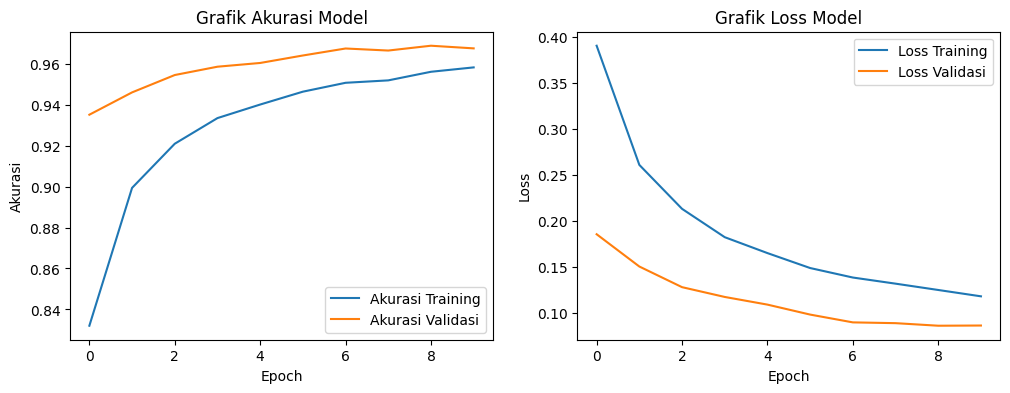

In [5]:
# 7. Visualisasi Hasil Pelatihan
# ==========================================================
# 'history.history' adalah dictionary yang menyimpan 'loss', 'accuracy', 
# 'val_loss', dan 'val_accuracy'

print("Membuat plot untuk Akurasi dan Loss...")

# --- Plot Akurasi ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Tampilkan plot
plt.show()

# Tahap A — Cell [5]: Simpan Model

In [6]:
# 8. Simpan Model yang Sudah Dilatih
# ==========================================================
# Kita simpan model ini ke root folder proyek agar
# 'app.py' bisa menemukannya dengan mudah.

MODEL_SAVE_PATH = 'eye_status_model.h5'

print(f"Menyimpan model ke: {MODEL_SAVE_PATH} ...")
model.save(MODEL_SAVE_PATH, save_format='h5')
print("Model berhasil disimpan!")

# Jangan lupa perbarui .gitignore jika belum:
# tambahkan baris:
# *.h5

Menyimpan model ke: eye_status_model.h5 ...
Model berhasil disimpan!


In [7]:
# 8. Simpan HANYA BOBOT (WEIGHTS) Model
# ==========================================================
# Ini adalah cara paling stabil untuk transfer model antar versi

MODEL_WEIGHTS_PATH = 'eye_status_model.weights.h5'

print(f"Menyimpan bobot model ke: {MODEL_WEIGHTS_PATH} ...")
model.save_weights(MODEL_WEIGHTS_PATH)
print("Bobot model berhasil disimpan!")

# Pastikan .gitignore Anda memiliki baris:
# *.h5
# (Ini akan mengabaikan file .h5 dan .weights.h5)

Menyimpan bobot model ke: eye_status_model.weights.h5 ...
Bobot model berhasil disimpan!


In [8]:
    import tensorflow as tf
    print(tf.__version__)

2.20.0
